# Sentiment Classification: BoW vs TF-IDF with Logistic Regression and Naive Bayes

**Dataset**: clapAI/MultiLingualSentiment  
**Pipeline**: Preprocess -> BoW / TF-IDF -> Logistic Regression / Naive Bayes  
**Metrics**: Accuracy, F1-score (weighted), Training time

---
## 0. Setup

In [1]:
import subprocess, sys

packages = [
    'datasets',
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'scikit-learn',
]

subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet'] + packages)
print('All packages installed.')

All packages installed.


In [2]:
import time
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

d:\NLP_Intern_RPG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
RANDOM_STATE = 42
MAX_FEATURES = 50_000
MAX_ITER     = 1_000

LABEL_ORDER  = ['negative', 'neutral', 'positive']

print('Config loaded.')
print(f'  MAX_FEATURES = {MAX_FEATURES:,}')

Config loaded.
  MAX_FEATURES = 50,000


---
## 1. Load Data

In [4]:
print('Loading dataset from HuggingFace...')
dataset = load_dataset('clapAI/MultiLingualSentiment')
print(dataset)

Loading dataset from HuggingFace...


DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'source', 'domain', 'language'],
        num_rows: 3147478
    })
    validation: Dataset({
        features: ['text', 'label', 'source', 'domain', 'language'],
        num_rows: 393435
    })
    test: Dataset({
        features: ['text', 'label', 'source', 'domain', 'language'],
        num_rows: 393436
    })
})


In [5]:
train_raw = dataset['train'].to_pandas()
test_raw  = dataset['test'].to_pandas()

print(f'Train rows : {len(train_raw):,}')
print(f'Test rows  : {len(test_raw):,}')
print(f'Columns    : {train_raw.columns.tolist()}')

Train rows : 3,147,478
Test rows  : 393,436
Columns    : ['text', 'label', 'source', 'domain', 'language']


In [6]:
print('Sample rows:')
train_raw[['text', 'label', 'language']].head(5)

Sample rows:


,text,label,language
0,A good environment with good food. Price is re...,positive,en
1,Tienes que leerla\nBonita historia histórica q...,positive,es
2,Buena compra\nTiene el tamaño perfecto. Fácil ...,positive,es
3,I need to come to NYC for work from Arizona al...,positive,en
4,コードレス設計で車内の掃除もできます。\nコードレス設計で車内の掃除もできます。砂と土なども...,positive,ja


In [7]:
print('Missing values:')
print(train_raw.isnull().sum())
print()
print('Label distribution (train):')
print(train_raw['label'].value_counts())
print()
print('Language count:', train_raw['language'].nunique())

Missing values:
text        0
label       0
source      0
domain      0
language    0
dtype: int64

Label distribution (train):
label
positive    1165038
negative    1149231
neutral      833209
Name: count, dtype: int64

Language count: 17


---
## 2. Preprocessing

In [8]:
def clean_text(text: str) -> str:
    """Basic multilingual-safe text cleaning."""
    if not isinstance(text, str):
        return ''

    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)   # remove URLs
    text = re.sub(r'<.*?>', ' ', text)             # remove HTML tags
    text = re.sub(r'[^\w\s]', ' ', text)           # remove punctuation
    text = re.sub(r'\d+', ' ', text)               # remove digits
    text = re.sub(r'\s+', ' ', text).strip()       # collapse whitespace

    return text

In [9]:
# Quick demo
examples = [
    'Great product! Highly recommended. https://shop.com',
    '<b>Very bad</b> quality... 100% disappointed!!!',
    'Livraison rapide, produit conforme. Je suis satisfait.',
]

for raw in examples:
    print(f'  before : {raw}')
    print(f'  after  : {clean_text(raw)}')
    print()

  before : Great product! Highly recommended. https://shop.com
  after  : great product highly recommended

  before : <b>Very bad</b> quality... 100% disappointed!!!
  after  : very bad quality disappointed

  before : Livraison rapide, produit conforme. Je suis satisfait.
  after  : livraison rapide produit conforme je suis satisfait



In [10]:
# Clean full train and test sets
print('Cleaning train set...')
t0 = time.time()
train_raw['text_clean'] = train_raw['text'].apply(clean_text)
print(f'  Done in {time.time() - t0:.1f}s.')

print('Cleaning test set...')
t0 = time.time()
test_raw['text_clean'] = test_raw['text'].apply(clean_text)
print(f'  Done in {time.time() - t0:.1f}s.')

# Drop empty rows
train_n = len(train_raw)
test_n  = len(test_raw)
train_raw = train_raw[train_raw['text_clean'].str.len() > 0].reset_index(drop=True)
test_raw  = test_raw[test_raw['text_clean'].str.len() > 0].reset_index(drop=True)

print(f'\nTrain: {train_n:,} -> {len(train_raw):,} (dropped {train_n - len(train_raw):,})')
print(f'Test:  {test_n:,} -> {len(test_raw):,} (dropped {test_n - len(test_raw):,})')

Cleaning train set...
  Done in 177.5s.
Cleaning test set...
  Done in 21.9s.

Train: 3,147,478 -> 3,147,246 (dropped 232)
Test:  393,436 -> 393,406 (dropped 30)


In [11]:
# Encode labels
le = LabelEncoder()
le.fit(LABEL_ORDER)

train_raw['label_enc'] = le.transform(train_raw['label'])
test_raw['label_enc']  = le.transform(test_raw['label'])

print('Label encoding:')
for cls, idx in zip(le.classes_, le.transform(le.classes_)):
    print(f'  {cls} -> {idx}')

Label encoding:
  negative -> 0
  neutral -> 1
  positive -> 2


In [12]:
# Use dataset's own train/test splits
X_train = train_raw['text_clean']
y_train = train_raw['label_enc']
X_test  = test_raw['text_clean']
y_test  = test_raw['label_enc']

print(f'X_train : {len(X_train):,} rows')
print(f'X_test  : {len(X_test):,} rows')
print()
print('Class distribution in y_train:')
print(pd.Series(y_train).value_counts().sort_index().rename(
    index={i: c for i, c in enumerate(le.classes_)}
))

X_train : 3,147,246 rows
X_test  : 393,406 rows

Class distribution in y_train:
label_enc
negative    1149173
neutral      833138
positive    1164935
Name: count, dtype: int64


---
## 3. Text Vectorization: Bag of Words

In [13]:
print('Fitting CountVectorizer (BoW)...')
t0 = time.time()

bow_vectorizer = CountVectorizer(
    max_features=MAX_FEATURES,
    min_df=2,
    ngram_range=(1, 2),
    strip_accents=None,     # keep accents for multilingual
    analyzer='word',
    token_pattern=r'(?u)\b\w+\b',
)

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow  = bow_vectorizer.transform(X_test)

print(f'Done in {time.time() - t0:.1f}s.')
print(f'Vocabulary size : {len(bow_vectorizer.vocabulary_):,}')
print(f'Matrix shape    : {X_train_bow.shape}')
print(f'Matrix sparsity : {1 - X_train_bow.nnz / (X_train_bow.shape[0] * X_train_bow.shape[1]):.4f}')

Fitting CountVectorizer (BoW)...
Done in 893.8s.
Vocabulary size : 50,000
Matrix shape    : (3147246, 50000)
Matrix sparsity : 0.9990


In [14]:
# Top 20 tokens by total frequency
bow_sum  = np.asarray(X_train_bow.sum(axis=0)).flatten()
bow_vocab = bow_vectorizer.get_feature_names_out()
top_bow  = pd.Series(bow_sum, index=bow_vocab).sort_values(ascending=False).head(20)

print('Top 20 tokens by frequency (BoW):')
print(top_bow.to_string())

Top 20 tokens by frequency (BoW):
the     5487305
and     3150672
a       2830445
i       2555047
to      2539583
was     1715254
of      1558668
it      1541429
in      1414543
is      1298508
for     1160039
that     933293
this     837901
but      834217
we       825190
on       796049
with     768115
you      741628
my       715391
not      709601


---
## 4. Text Vectorization: TF-IDF

In [15]:
print('Fitting TfidfVectorizer...')
t0 = time.time()

tfidf_vectorizer = TfidfVectorizer(
    max_features=MAX_FEATURES,
    min_df=2,
    ngram_range=(1, 2),
    strip_accents=None,
    analyzer='word',
    token_pattern=r'(?u)\b\w+\b',
    sublinear_tf=True,       # use 1 + log(tf) instead of raw tf
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf  = tfidf_vectorizer.transform(X_test)

print(f'Done in {time.time() - t0:.1f}s.')
print(f'Vocabulary size : {len(tfidf_vectorizer.vocabulary_):,}')
print(f'Matrix shape    : {X_train_tfidf.shape}')
print(f'Matrix sparsity : {1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]):.4f}')

Fitting TfidfVectorizer...
Done in 909.0s.
Vocabulary size : 50,000
Matrix shape    : (3147246, 50000)
Matrix sparsity : 0.9990


In [16]:
# Top 20 tokens by mean TF-IDF weight
tfidf_mean  = np.asarray(X_train_tfidf.mean(axis=0)).flatten()
tfidf_vocab = tfidf_vectorizer.get_feature_names_out()
top_tfidf   = pd.Series(tfidf_mean, index=tfidf_vocab).sort_values(ascending=False).head(20)

print('Top 20 tokens by mean TF-IDF weight:')
print(top_tfidf.to_string())

Top 20 tokens by mean TF-IDF weight:
the     0.020282
and     0.016664
i       0.016599
a       0.016063
to      0.014482
it      0.011264
was     0.010567
is      0.010485
of      0.010375
in      0.010347
de      0.010052
for     0.009548
this    0.007735
but     0.007666
on      0.007294
la      0.007253
that    0.007186
my      0.007176
not     0.007169
with    0.006920


In [17]:
# Compare: which top-BoW tokens are NOT in top-TF-IDF?
bow_top_set   = set(top_bow.index)
tfidf_top_set = set(top_tfidf.index)

print('In BoW top-20 but NOT in TF-IDF top-20:')
print(bow_top_set - tfidf_top_set)
print()
print('In TF-IDF top-20 but NOT in BoW top-20:')
print(tfidf_top_set - bow_top_set)

In BoW top-20 but NOT in TF-IDF top-20:
{'we', 'you'}

In TF-IDF top-20 but NOT in BoW top-20:
{'de', 'la'}


---
## 5. Training

In [18]:
def train_and_evaluate(model, X_tr, X_te, y_tr, y_te, label_names):
    """Train a classifier and return metrics dict."""
    # Train
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = time.time() - t0

    # Predict
    y_pred = model.predict(X_te)

    # Metrics
    acc = accuracy_score(y_te, y_pred)
    f1  = f1_score(y_te, y_pred, average='weighted')
    report = classification_report(y_te, y_pred, target_names=label_names)
    cm     = confusion_matrix(y_te, y_pred)

    return {
        'accuracy'              : acc,
        'f1_weighted'           : f1,
        'train_time_sec'        : train_time,
        'classification_report' : report,
        'confusion_matrix'      : cm,
    }

In [19]:
label_names = le.classes_.tolist()

experiments = {
    'BoW + Logistic Regression': {
        'model'  : LogisticRegression(max_iter=MAX_ITER, random_state=RANDOM_STATE, solver='lbfgs', n_jobs=-1),
        'X_train': X_train_bow,
        'X_test' : X_test_bow,
    },
    'BoW + Naive Bayes': {
        'model'  : MultinomialNB(),
        'X_train': X_train_bow,
        'X_test' : X_test_bow,
    },
    'TF-IDF + Logistic Regression': {
        'model'  : LogisticRegression(max_iter=MAX_ITER, random_state=RANDOM_STATE, solver='saga', n_jobs=-1),
        'X_train': X_train_tfidf,
        'X_test' : X_test_tfidf,
    },
    'TF-IDF + Naive Bayes': {
        'model'  : MultinomialNB(),
        'X_train': X_train_tfidf,
        'X_test' : X_test_tfidf,
    },
}

print(f'Experiments: {list(experiments.keys())}')

Experiments: ['BoW + Logistic Regression', 'BoW + Naive Bayes', 'TF-IDF + Logistic Regression', 'TF-IDF + Naive Bayes']


In [20]:
results = {}

for name, cfg in experiments.items():
    print(f'Running: {name} ...')
    results[name] = train_and_evaluate(
        model       = cfg['model'],
        X_tr        = cfg['X_train'],
        X_te        = cfg['X_test'],
        y_tr        = y_train,
        y_te        = y_test,
        label_names = label_names,
    )
    r = results[name]
    print(f'  Accuracy    : {r["accuracy"]:.4f}')
    print(f'  F1 weighted : {r["f1_weighted"]:.4f}')
    print(f'  Train time  : {r["train_time_sec"]:.2f}s')
    print()

Running: BoW + Logistic Regression ...
  Accuracy    : 0.6769
  F1 weighted : 0.6706
  Train time  : 2909.24s

Running: BoW + Naive Bayes ...
  Accuracy    : 0.5770
  F1 weighted : 0.5733
  Train time  : 1.85s

Running: TF-IDF + Logistic Regression ...
  Accuracy    : 0.6861
  F1 weighted : 0.6809
  Train time  : 194.71s

Running: TF-IDF + Naive Bayes ...
  Accuracy    : 0.6253
  F1 weighted : 0.6233
  Train time  : 0.84s



---
## 6. Comparison

In [21]:
# Summary table
summary = pd.DataFrame([
    {
        'experiment'     : name,
        'accuracy'       : r['accuracy'],
        'f1_weighted'    : r['f1_weighted'],
        'train_time_sec' : r['train_time_sec'],
    }
    for name, r in results.items()
])

summary = summary.sort_values('f1_weighted', ascending=False).reset_index(drop=True)
summary[['accuracy', 'f1_weighted']] = summary[['accuracy', 'f1_weighted']].round(4)
summary['train_time_sec'] = summary['train_time_sec'].round(2)

print('Results summary (sorted by F1 weighted):')
print(summary.to_string(index=False))

Results summary (sorted by F1 weighted):
                  experiment  accuracy  f1_weighted  train_time_sec
TF-IDF + Logistic Regression    0.6861       0.6809          194.71
   BoW + Logistic Regression    0.6769       0.6706         2909.24
        TF-IDF + Naive Bayes    0.6253       0.6233            0.84
           BoW + Naive Bayes    0.5770       0.5733            1.85


In [22]:
# Classification report per experiment
for name, r in results.items():
    print('=' * 60)
    print(f'  {name}')
    print('=' * 60)
    print(r['classification_report'])
    print()

  BoW + Logistic Regression
              precision    recall  f1-score   support

    negative       0.75      0.67      0.71    143645
     neutral       0.66      0.47      0.55    104145
    positive       0.63      0.83      0.72    145616

    accuracy                           0.68    393406
   macro avg       0.68      0.66      0.66    393406
weighted avg       0.68      0.68      0.67    393406


  BoW + Naive Bayes
              precision    recall  f1-score   support

    negative       0.73      0.45      0.55    143645
     neutral       0.50      0.55      0.52    104145
    positive       0.55      0.72      0.63    145616

    accuracy                           0.58    393406
   macro avg       0.59      0.57      0.57    393406
weighted avg       0.60      0.58      0.57    393406


  TF-IDF + Logistic Regression
              precision    recall  f1-score   support

    negative       0.76      0.68      0.72    143645
     neutral       0.67      0.50      0.57    1

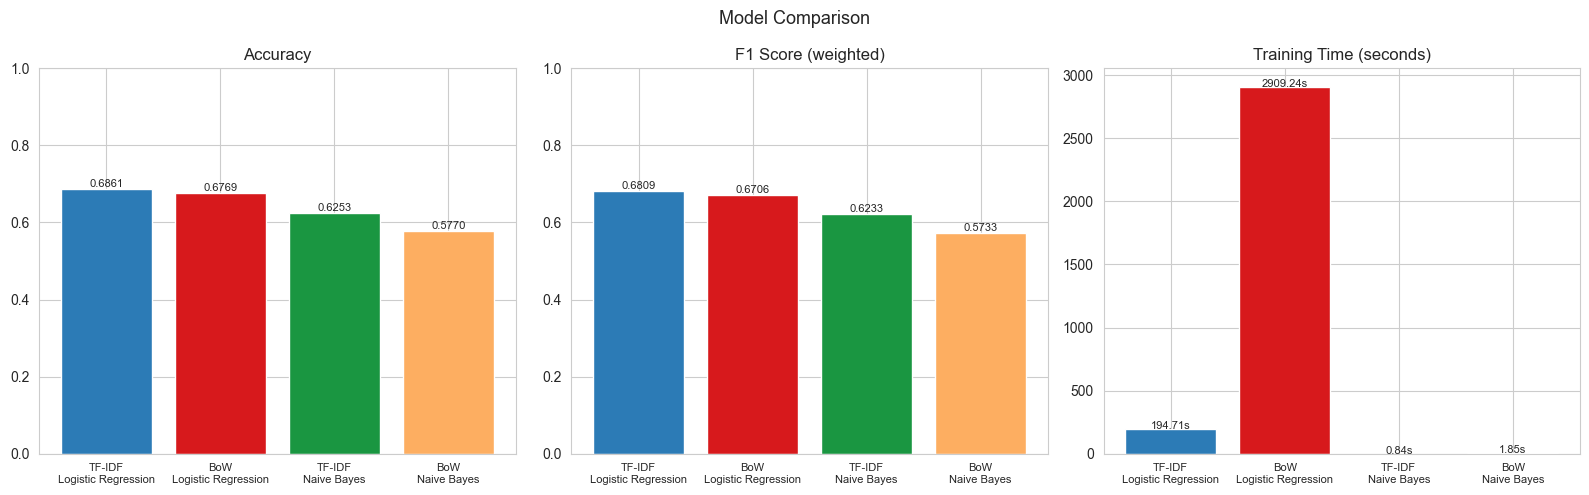

In [23]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Comparison', fontsize=13)

x       = range(len(summary))
labels  = [n.replace(' + ', '\n') for n in summary['experiment']]
palette = ['#2c7bb6', '#d7191c', '#1a9641', '#fdae61']

# Accuracy
axes[0].bar(x, summary['accuracy'], color=palette)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=8)
axes[0].set_title('Accuracy')
axes[0].set_ylim(0, 1)
for i, v in enumerate(summary['accuracy']):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=8)

# F1 weighted
axes[1].bar(x, summary['f1_weighted'], color=palette)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, fontsize=8)
axes[1].set_title('F1 Score (weighted)')
axes[1].set_ylim(0, 1)
for i, v in enumerate(summary['f1_weighted']):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=8)

# Training time
axes[2].bar(x, summary['train_time_sec'], color=palette)
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels, fontsize=8)
axes[2].set_title('Training Time (seconds)')
for i, v in enumerate(summary['train_time_sec']):
    axes[2].text(i, v + 0.1, f'{v:.2f}s', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

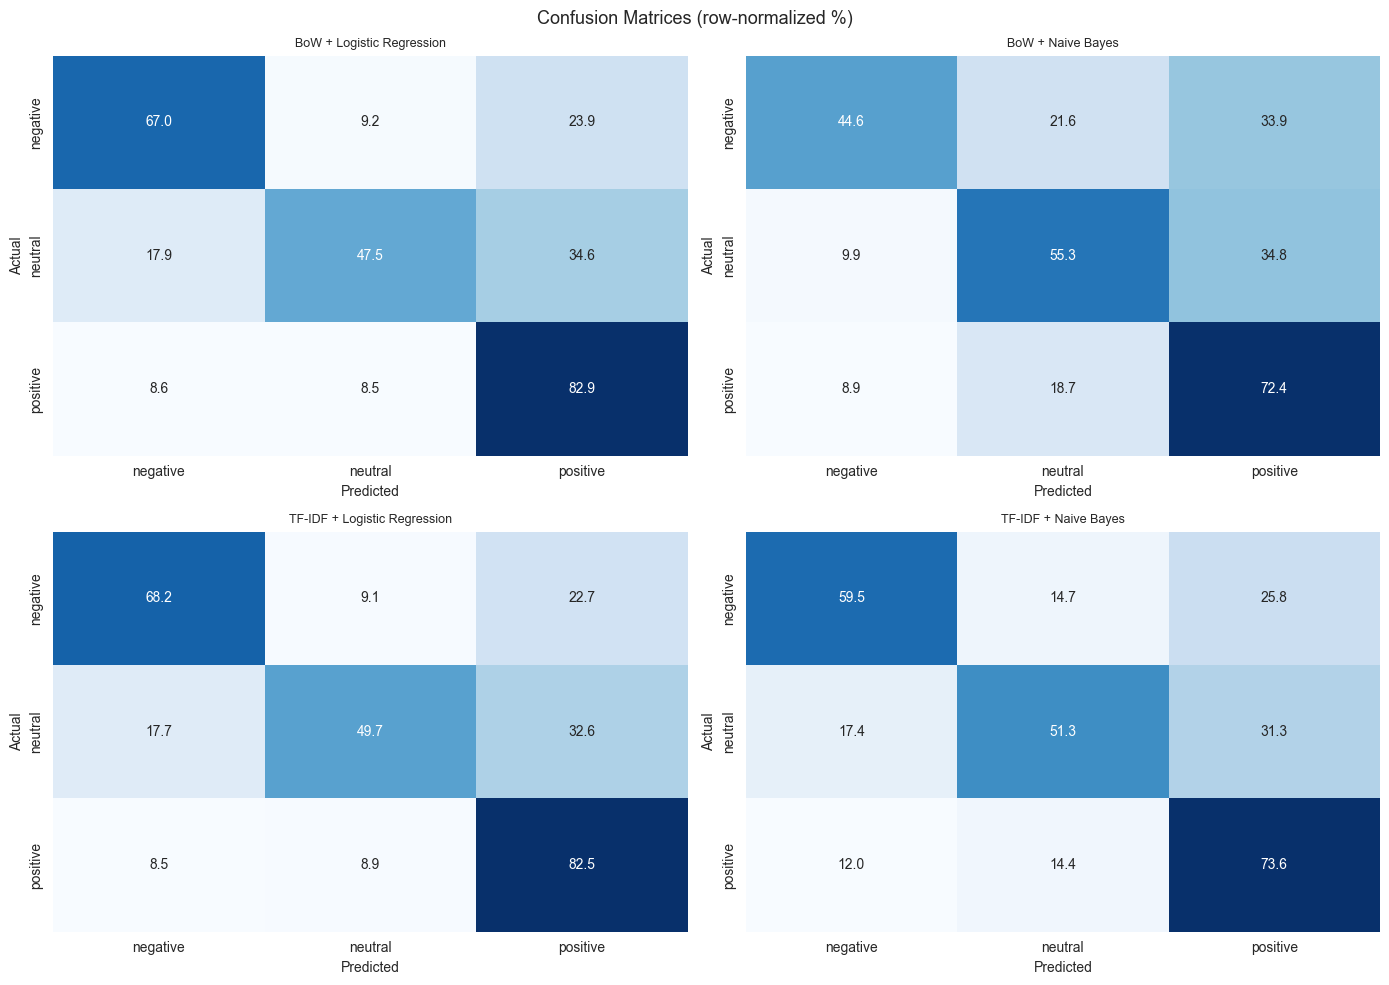

In [24]:
# Confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Confusion Matrices (row-normalized %)', fontsize=13)

for ax, (name, r) in zip(axes.flatten(), results.items()):
    cm = r['confusion_matrix']
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(
        cm_pct,
        annot=True,
        fmt='.1f',
        cmap='Blues',
        xticklabels=label_names,
        yticklabels=label_names,
        ax=ax,
        cbar=False,
    )
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

---
## 7. Conclusion

In [25]:
best    = summary.iloc[0]
fastest = summary.sort_values('train_time_sec').iloc[0]

print('Best by F1 score:')
print(f'  {best["experiment"]}')
print(f'  Accuracy : {best["accuracy"]:.4f}')
print(f'  F1       : {best["f1_weighted"]:.4f}')
print(f'  Time     : {best["train_time_sec"]:.2f}s')
print()
print('Fastest to train:')
print(f'  {fastest["experiment"]}')
print(f'  Time     : {fastest["train_time_sec"]:.2f}s')
print(f'  F1       : {fastest["f1_weighted"]:.4f}')
print()
print('Full ranking:')
print(summary[['experiment', 'accuracy', 'f1_weighted', 'train_time_sec']].to_string(index=False))

Best by F1 score:
  TF-IDF + Logistic Regression
  Accuracy : 0.6861
  F1       : 0.6809
  Time     : 194.71s

Fastest to train:
  TF-IDF + Naive Bayes
  Time     : 0.84s
  F1       : 0.6233

Full ranking:
                  experiment  accuracy  f1_weighted  train_time_sec
TF-IDF + Logistic Regression    0.6861       0.6809          194.71
   BoW + Logistic Regression    0.6769       0.6706         2909.24
        TF-IDF + Naive Bayes    0.6253       0.6233            0.84
           BoW + Naive Bayes    0.5770       0.5733            1.85
